In [42]:
# IMPORT LIBRARIES

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential #layers
from tensorflow.keras.layers import Dense, Flatten #dense : fully connected , flatten : بيحول الصور من vectt g matrix
from tensorflow.keras.datasets import mnist #dataset جاهزة
from tensorflow.keras.optimizers import Adam # weights اثناء التدريب عشان يقلل ال loss يعدل ال
from tensorflow.keras.callbacks import EarlyStopping #نحاول نقلل ال overfitting



In [43]:
#tf.random.set_seed(42)
#np.random.seed(42)

In [44]:
# LOAD DATASET

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)



Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


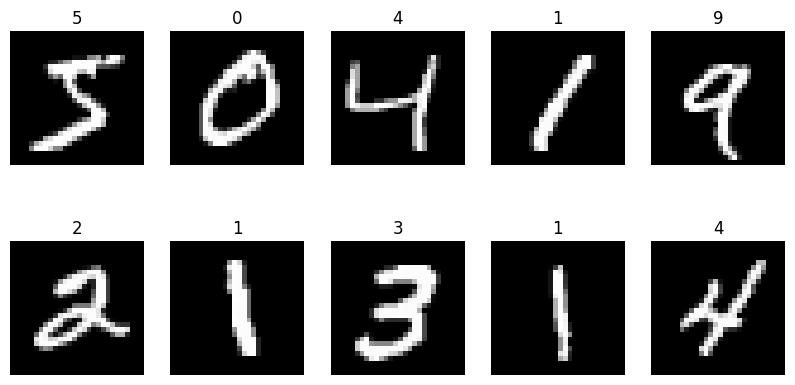

In [45]:
# VISUALIZE SAMPLE IMAGES

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1) # 2 rows , 5 columns
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off') #نشيل الحور عشان تبان

plt.show()


In [46]:
# DATA PREPROCESSING

# Normalize pixel values نخلى القيم ب1
X_train = X_train / 255.0
X_test = X_test / 255.0

# EARLY STOPPING

early_stop = EarlyStopping(
    patience=3,
    restore_best_weights=True
)


In [47]:

# EXPERIMENT 1
# RELU ACTIVATION

model1 = Sequential([
    Flatten(input_shape=(28,28)), #عشان الصورة 28*28 و بنحولها ل 784

    Dense(128, activation='relu'), #hiddden 128 neurons , fast & deep learning

    Dense(10, activation='softmax') # بتخلى النتيجة prob
])

model1.summary()


# COMPILE MODEL 1

model1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'] # يعرض ال acc اثناء التدريب
)


# TRAIN MODEL 1

history1 = model1.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9201 - loss: 0.2831 - val_accuracy: 0.9577 - val_loss: 0.1498
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9645 - loss: 0.1238 - val_accuracy: 0.9682 - val_loss: 0.1110
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9754 - loss: 0.0842 - val_accuracy: 0.9707 - val_loss: 0.0995
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9829 - loss: 0.0612 - val_accuracy: 0.9719 - val_loss: 0.0978
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9874 - loss: 0.0458 - val_accuracy: 0.9711 - val_loss: 0.0981
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9912 - loss: 0.0340 - val_accuracy: 0.9724 - val_loss: 0.0981
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9937 - loss: 0.0261 - val_accuracy: 0.9730 - val_loss: 0.0969
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9953 - loss: 0.0198 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9745 - loss: 0.0880

Experiment 1 Results
Test Loss: 0.08797554671764374
Test Accuracy: 0.9745000004768372


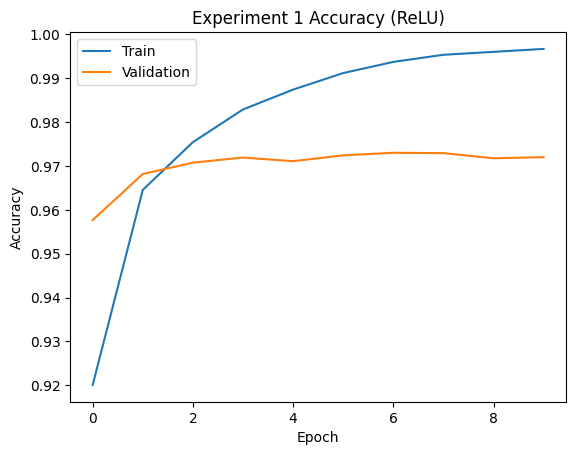

In [48]:

# EVALUATE MODEL 1

test_loss1, test_accuracy1 = model1.evaluate(X_test, y_test) # نختبر الموديل على داتا جديدة

print("\nExperiment 1 Results")
print("Test Loss:", test_loss1)
print("Test Accuracy:", test_accuracy1)


# ACCURACY GRAPH - EXPERIMENT 1

plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])

plt.title('Experiment 1 Accuracy (ReLU)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

In [49]:

# EXPERIMENT 2
# SIGMOID ACTIVATION

model2 = Sequential([
    Flatten(input_shape=(28,28)), # ابطأ شويه

    Dense(128, activation='sigmoid'),

    Dense(10, activation='softmax')
])

model2.summary()


# COMPILE MODEL 2

model2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# TRAIN MODEL 2

history2 = model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8856 - loss: 0.4391 - val_accuracy: 0.9327 - val_loss: 0.2415
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9374 - loss: 0.2187 - val_accuracy: 0.9485 - val_loss: 0.1834
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9525 - loss: 0.1628 - val_accuracy: 0.9578 - val_loss: 0.1513


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9307 - loss: 0.2441

Experiment 2 Results
Test Loss: 0.2440788596868515
Test Accuracy: 0.9307000041007996


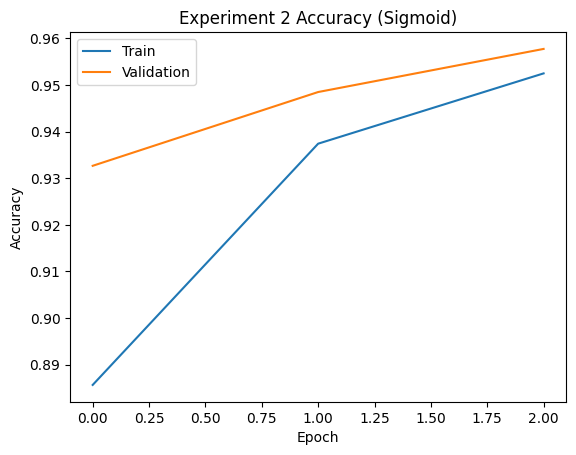

In [50]:

# EVALUATE MODEL 2

test_loss2, test_accuracy2 = model2.evaluate(X_test, y_test)

print("\nExperiment 2 Results")
print("Test Loss:", test_loss2)
print("Test Accuracy:", test_accuracy2)


# ACCURACY GRAPH - EXPERIMENT 2

plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])

plt.title('Experiment 2 Accuracy (Sigmoid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

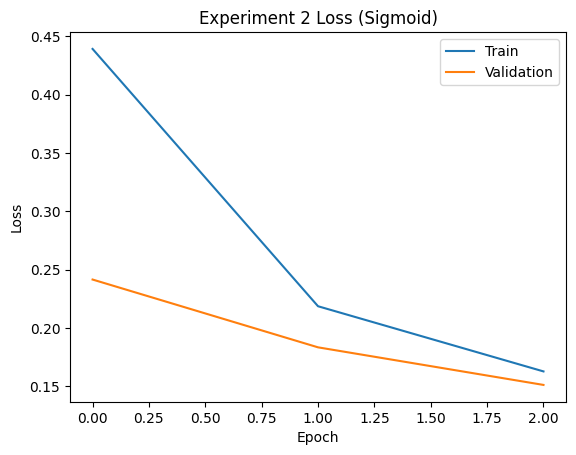

In [51]:

# LOSS GRAPH - EXPERIMENT 2


plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

plt.title('Experiment 2 Loss (Sigmoid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()


In [52]:

# EXPERIMENT 3
# TANH ACTIVATION


model3 = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(128, activation='tanh'), #-1,1

    Dense(10, activation='softmax')
])

model3.summary()

# COMPILE MODEL 3

model3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# TRAIN MODEL 3

history3 = model3.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)



Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9104 - loss: 0.3140 - val_accuracy: 0.9477 - val_loss: 0.1867
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9547 - loss: 0.1572 - val_accuracy: 0.9610 - val_loss: 0.1377
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9696 - loss: 0.1077 - val_accuracy: 0.9657 - val_loss: 0.1157


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9453 - loss: 0.1813

Experiment 3 Results
Test Loss: 0.1812542825937271
Test Accuracy: 0.9452999830245972


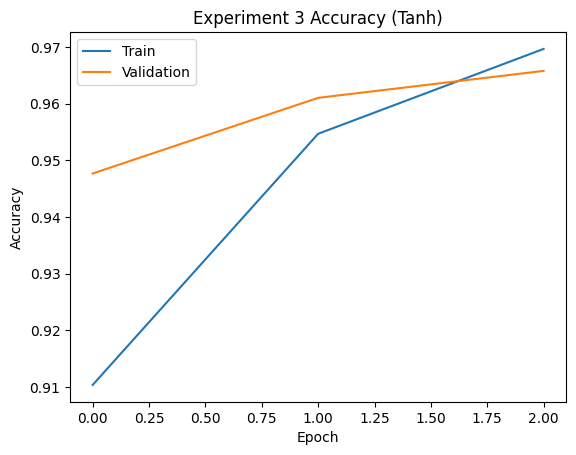

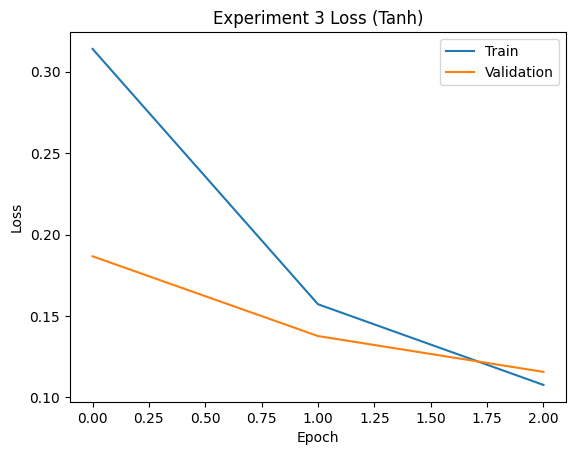

In [53]:


# EVALUATE MODEL 3

test_loss3, test_accuracy3 = model3.evaluate(X_test, y_test)

print("\nExperiment 3 Results")
print("Test Loss:", test_loss3)
print("Test Accuracy:", test_accuracy3)


# ACCURACY GRAPH - EXPERIMENT 3

plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])

plt.title('Experiment 3 Accuracy (Tanh)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()


# LOSS GRAPH - EXPERIMENT 3

plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])

plt.title('Experiment 3 Loss (Tanh)')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()



In [54]:

# FINAL COMPARISON

print("\n========== FINAL COMPARISON ==========")

print(f"ReLU Model Accuracy: {test_accuracy1:.4f}")
print(f"ReLU Model Loss: {test_loss1:.4f}")

print("--------------------------------------")

print(f"Sigmoid Model Accuracy: {test_accuracy2:.4f}")
print(f"Sigmoid Model Loss: {test_loss2:.4f}")

print("--------------------------------------")

print(f"Tanh Model Accuracy: {test_accuracy3:.4f}")
print(f"Tanh Model Loss: {test_loss3:.4f}")


========== FINAL COMPARISON ==========
ReLU Model Accuracy: 0.9745
ReLU Model Loss: 0.0880
--------------------------------------
Sigmoid Model Accuracy: 0.9307
Sigmoid Model Loss: 0.2441
--------------------------------------
Tanh Model Accuracy: 0.9453
Tanh Model Loss: 0.1813
